# 01 — Data Loading & Cleaning
**Author:** Pasindu Malinda

**Pipeline:** HDFS raw CSV → Schema validation → Per-dataset cleaning → Logical integrity checks → Core join → HDFS Parquet + local CSV sample


## 1. Environment Setup & Spark Session

In [1]:
import os
import sys

from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField,
    StringType, IntegerType, DoubleType, TimestampType, BooleanType
)

spark = (
    SparkSession.builder
    .appName("ecommerce-01-data-loading-cleaning")
    .master("local[*]")
    .config("spark.hadoop.fs.defaultFS", "hdfs://localhost:9000")
    # keep shuffle partitions small — dataset is ~100k rows, not billions
    .config("spark.sql.shuffle.partitions", "8")
    # enable adaptive query execution (Spark 3+)
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} ready  |  cores: {spark.sparkContext.defaultParallelism}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/22 09:10:47 WARN Utils: Your hostname, Pasindus-MacBook-Pro-2.local, resolves to a loopback address: 127.0.0.1; using 192.168.8.188 instead (on interface en0)
26/04/22 09:10:47 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/22 09:10:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.1 ready  |  cores: 8


In [14]:
# ── plot libraries (standard in Jupyter environments)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# consistent style across all plots
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
TITLE_PAD = 14
FIG_DPI   = 120

print('Plot libraries ready')

Plot libraries ready


## 2. Path Configuration

In [2]:
HDFS_RAW     = "hdfs://localhost:9000/ecommerce/raw"
HDFS_OUTPUT  = "hdfs://localhost:9000/ecommerce/output"
LOCAL_OUTPUT = "/Users/pasindumalinda/Project-04/ecommerce-recommendation-spark/data/processed"

os.makedirs(LOCAL_OUTPUT, exist_ok=True)

print(f"HDFS raw    : {HDFS_RAW}")
print(f"HDFS output : {HDFS_OUTPUT}")
print(f"Local output: {LOCAL_OUTPUT}")

HDFS raw    : hdfs://localhost:9000/ecommerce/raw
HDFS output : hdfs://localhost:9000/ecommerce/output
Local output: /Users/pasindumalinda/Project-04/ecommerce-recommendation-spark/data/processed


## 3. Explicit Schema Definitions

Defining schemas explicitly avoids Spark's full-scan inference pass,
enforces correct types from the first read, and makes schema drift visible immediately.

In [3]:
schema_orders = StructType([
    StructField("order_id",                     StringType(),    False),
    StructField("customer_id",                  StringType(),    False),
    StructField("order_status",                 StringType(),    True),
    StructField("order_purchase_timestamp",      TimestampType(), True),
    StructField("order_approved_at",             TimestampType(), True),
    StructField("order_delivered_carrier_date",  TimestampType(), True),
    StructField("order_delivered_customer_date", TimestampType(), True),
    StructField("order_estimated_delivery_date", TimestampType(), True),
])

schema_order_items = StructType([
    StructField("order_id",           StringType(),    False),
    StructField("order_item_id",       IntegerType(),   True),
    StructField("product_id",          StringType(),    False),
    StructField("seller_id",           StringType(),    True),
    StructField("shipping_limit_date", TimestampType(), True),
    StructField("price",               DoubleType(),    True),
    StructField("freight_value",       DoubleType(),    True),
])

schema_products = StructType([
    StructField("product_id",                  StringType(),  False),
    StructField("product_category_name",        StringType(),  True),
    StructField("product_name_lenght",          DoubleType(),  True),  # typo is in source data
    StructField("product_description_lenght",   DoubleType(),  True),  # typo is in source data
    StructField("product_photos_qty",           DoubleType(),  True),
    StructField("product_weight_g",             DoubleType(),  True),
    StructField("product_length_cm",            DoubleType(),  True),
    StructField("product_height_cm",            DoubleType(),  True),
    StructField("product_width_cm",             DoubleType(),  True),
])

schema_customers = StructType([
    StructField("customer_id",             StringType(),  False),
    StructField("customer_unique_id",       StringType(),  True),
    StructField("customer_zip_code_prefix", IntegerType(), True),
    StructField("customer_city",           StringType(),  True),
    StructField("customer_state",          StringType(),  True),
])

schema_translation = StructType([
    StructField("product_category_name",         StringType(), True),
    StructField("product_category_name_english",  StringType(), True),
])

print("Schemas defined for 5 datasets")

Schemas defined for 5 datasets


## 4. Load Raw CSV Files from HDFS

In [4]:
READ_OPTS = {"header": "true", "timestampFormat": "yyyy-MM-dd HH:mm:ss"}

df_orders_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_orders)
    .csv(f"{HDFS_RAW}/olist_orders_dataset.csv")
)

df_items_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_order_items)
    .csv(f"{HDFS_RAW}/olist_order_items_dataset.csv")
)

df_products_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_products)
    .csv(f"{HDFS_RAW}/olist_products_dataset.csv")
)

df_customers_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_customers)
    .csv(f"{HDFS_RAW}/olist_customers_dataset.csv")
)

df_translation_raw = (
    spark.read.options(**READ_OPTS)
    .schema(schema_translation)
    .csv(f"{HDFS_RAW}/product_category_name_translation.csv")
)

print("All raw DataFrames loaded from HDFS")

All raw DataFrames loaded from HDFS


## 5. Schema & Row Count Audit

In [8]:
RAW = {
    'orders':      df_orders_raw,
    'order_items': df_items_raw,
    'products':    df_products_raw,
    'customers':   df_customers_raw,
    'translation': df_translation_raw,
}

print(f"{'Dataset':<18} {'Rows':>10} {'Columns':>9}")
print('-' * 40)
row_counts = {}
for name, df in RAW.items():
    r = df.count()
    row_counts[name] = r
    print(f"{name:<18} {r:>10,} {len(df.columns):>9}")

Dataset                  Rows   Columns
----------------------------------------
orders                 99,441         8
order_items           112,650         7
products               32,951         9
customers              99,441         5
translation                71         2


In [9]:
for name, df in RAW.items():
    print(f'\n{'='*55}')
    print(f'Schema: {name}')
    df.printSchema()


Schema: orders
root
 |-- order_id: string (nullable = true)
 |-- customer_id: string (nullable = true)
 |-- order_status: string (nullable = true)
 |-- order_purchase_timestamp: timestamp (nullable = true)
 |-- order_approved_at: timestamp (nullable = true)
 |-- order_delivered_carrier_date: timestamp (nullable = true)
 |-- order_delivered_customer_date: timestamp (nullable = true)
 |-- order_estimated_delivery_date: timestamp (nullable = true)


Schema: order_items
root
 |-- order_id: string (nullable = true)
 |-- order_item_id: integer (nullable = true)
 |-- product_id: string (nullable = true)
 |-- seller_id: string (nullable = true)
 |-- shipping_limit_date: timestamp (nullable = true)
 |-- price: double (nullable = true)
 |-- freight_value: double (nullable = true)


Schema: products
root
 |-- product_id: string (nullable = true)
 |-- product_category_name: string (nullable = true)
 |-- product_name_lenght: double (nullable = true)
 |-- product_description_lenght: double (nullabl

### 5.1 Row Count Comparison Across Datasets

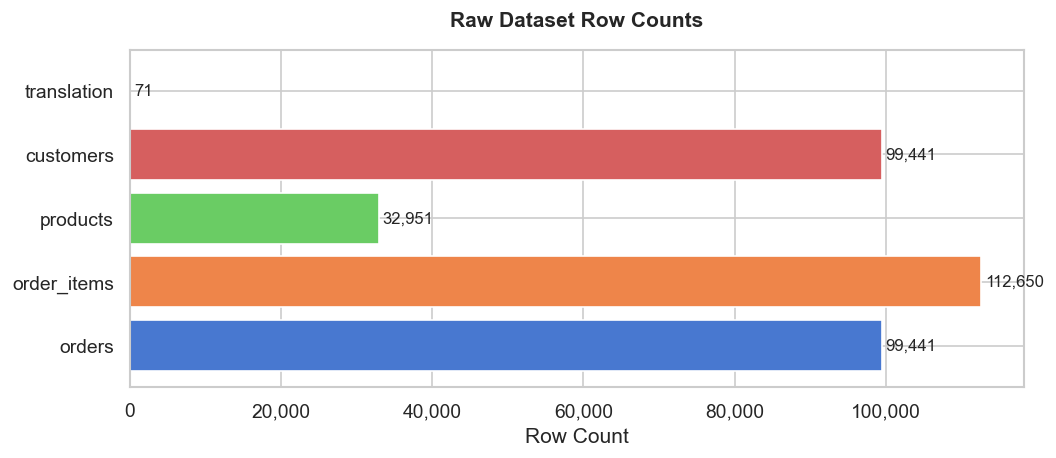

In [10]:
fig, ax = plt.subplots(figsize=(9, 4), dpi=FIG_DPI)

names  = list(row_counts.keys())
counts = list(row_counts.values())
bars   = ax.barh(names, counts, color=sns.color_palette('muted', len(names)), edgecolor='white')

for bar, val in zip(bars, counts):
    ax.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10)

ax.set_xlabel('Row Count')
ax.set_title('Raw Dataset Row Counts', pad=TITLE_PAD, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 6. Null / Missing Value Profiling

In [11]:
def null_audit(df, label):
    """Return null counts and % per column; print summary."""
    total = df.count()
    agg_exprs = [F.sum(F.col(c).isNull().cast('int')).alias(c) for c in df.columns]
    counts = df.select(agg_exprs).collect()[0].asDict()
    print(f'\n[{label}]  total rows: {total:,}')
    print(f"  {'Column':<45} {'Nulls':>7}  {'%':>6}")
    print(f"  {'-'*60}")
    result = {}
    for col, n in counts.items():
        pct  = n / total * 100
        flag = '  << ACTION' if n > 0 else ''
        print(f"  {col:<45} {n:>7,}  {pct:>5.1f}%{flag}")
        result[col] = pct
    return result

null_profiles = {}
for name, df in RAW.items():
    null_profiles[name] = null_audit(df, name)


[orders]  total rows: 99,441
  Column                                          Nulls       %
  ------------------------------------------------------------
  order_id                                            0    0.0%
  customer_id                                         0    0.0%
  order_status                                        0    0.0%
  order_purchase_timestamp                            0    0.0%
  order_approved_at                                 160    0.2%  << ACTION
  order_delivered_carrier_date                    1,783    1.8%  << ACTION
  order_delivered_customer_date                   2,965    3.0%  << ACTION
  order_estimated_delivery_date                       0    0.0%

[order_items]  total rows: 112,650
  Column                                          Nulls       %
  ------------------------------------------------------------
  order_id                                            0    0.0%
  order_item_id                                       0    0.0%
  produ

### 6.1 Null Percentage Heatmap

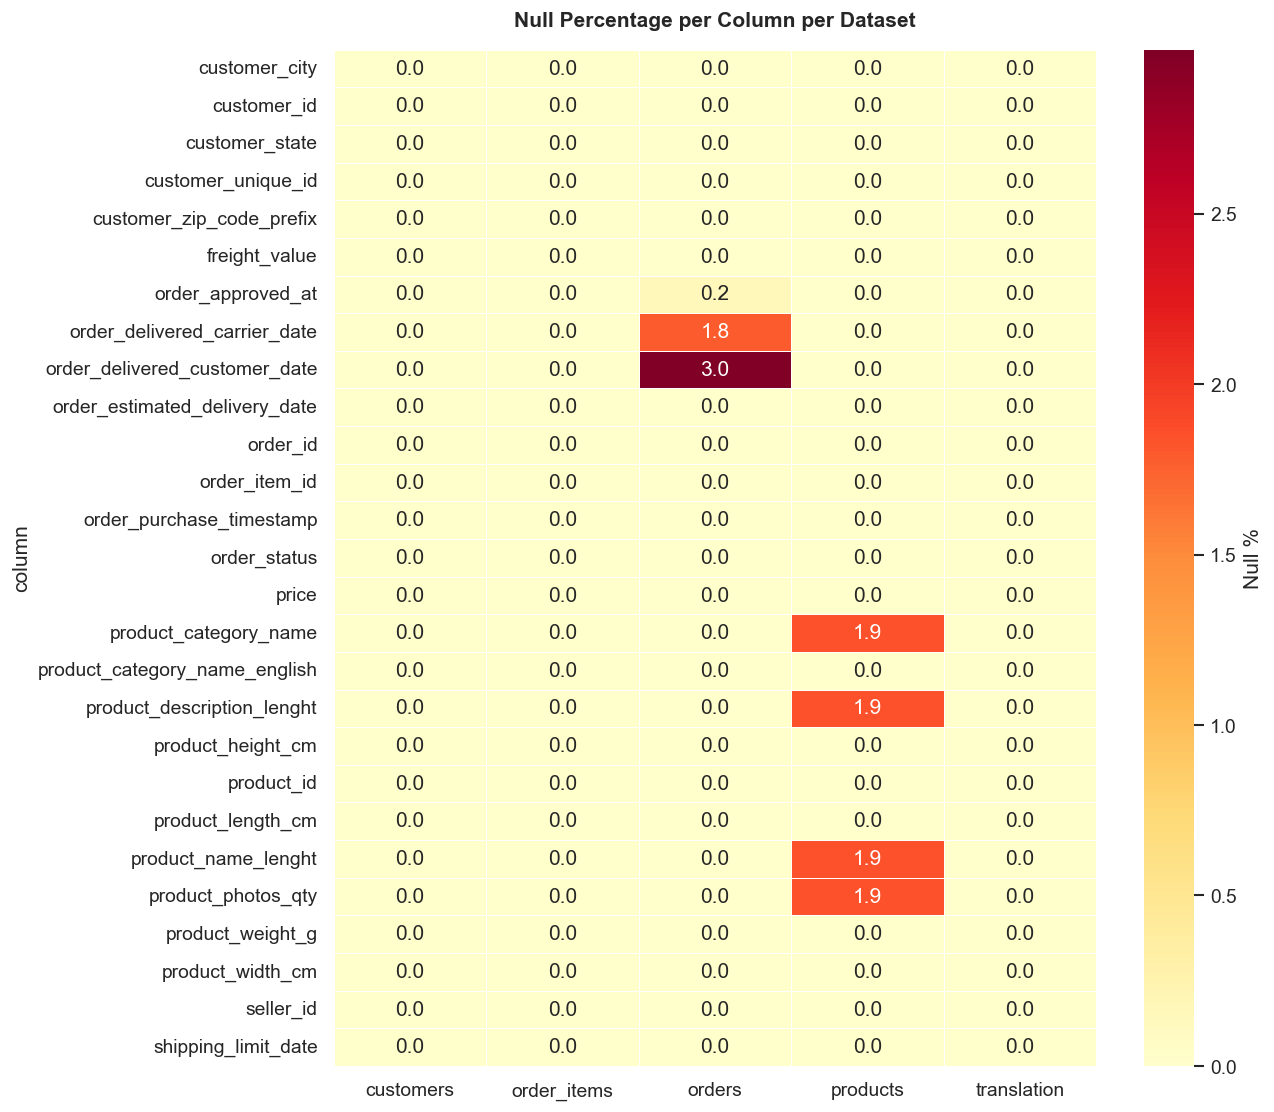

In [15]:
# collect null % into a pandas frame for heatmap
all_cols, all_vals, all_ds = [], [], []
for ds_name, profile in null_profiles.items():
    for col, pct in profile.items():
        all_cols.append(col)
        all_vals.append(pct)
        all_ds.append(ds_name)

heat_df = pd.DataFrame({'dataset': all_ds, 'column': all_cols, 'null_pct': all_vals})
heat_pivot = heat_df.pivot(index='column', columns='dataset', values='null_pct').fillna(0)

fig, ax = plt.subplots(figsize=(11, max(6, len(heat_pivot)*0.35)), dpi=FIG_DPI)
sns.heatmap(
    heat_pivot, annot=True, fmt='.1f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, cbar_kws={'label': 'Null %'}
)
ax.set_title('Null Percentage per Column per Dataset', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('')
plt.tight_layout()
plt.show()

## 7. Orders — Univariate & Temporal EDA

### 7.1 Order Status Distribution

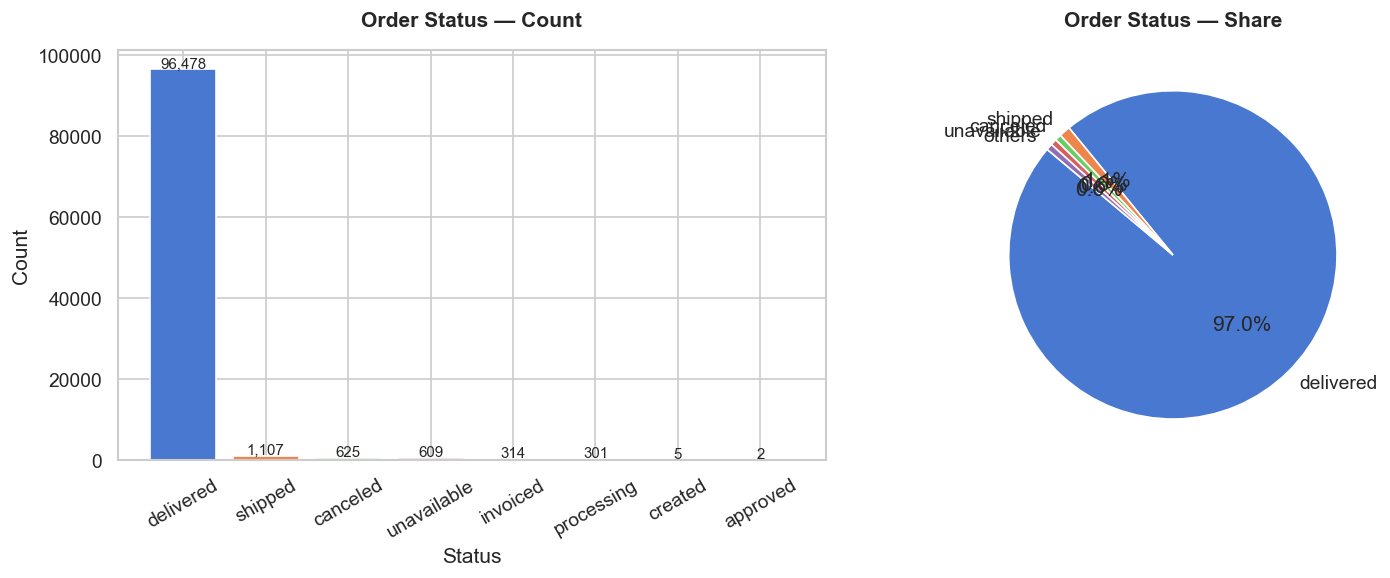

order_status  count
   delivered  96478
     shipped   1107
    canceled    625
 unavailable    609
    invoiced    314
  processing    301
     created      5
    approved      2


In [22]:
status_pd = (
    df_orders_raw
    .groupBy('order_status').count()
    .orderBy(F.desc('count'))
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=FIG_DPI)

# bar
colors = sns.color_palette('muted', len(status_pd))
bars = axes[0].bar(status_pd['order_status'], status_pd['count'], color=colors, edgecolor='white')
for bar, val in zip(bars, status_pd['count']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f'{val:,}', ha='center', fontsize=9)
axes[0].set_title('Order Status — Count', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Status')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

# pie (top 4 only for readability)
top4 = status_pd.head(4).copy()
rest = status_pd.iloc[4:]['count'].sum()
top4 = pd.concat([top4, pd.DataFrame([{'order_status': 'others', 'count': rest}])], ignore_index=True)
axes[1].pie(
    top4['count'], labels=top4['order_status'],
    autopct='%1.1f%%', startangle=140,
    colors=sns.color_palette('muted', len(top4))
)
axes[1].set_title('Order Status — Share', pad=TITLE_PAD, fontweight='bold')

plt.tight_layout()
plt.show()
print(status_pd.to_string(index=False))

### 7.2 Monthly Order Volume (Growth Trend)

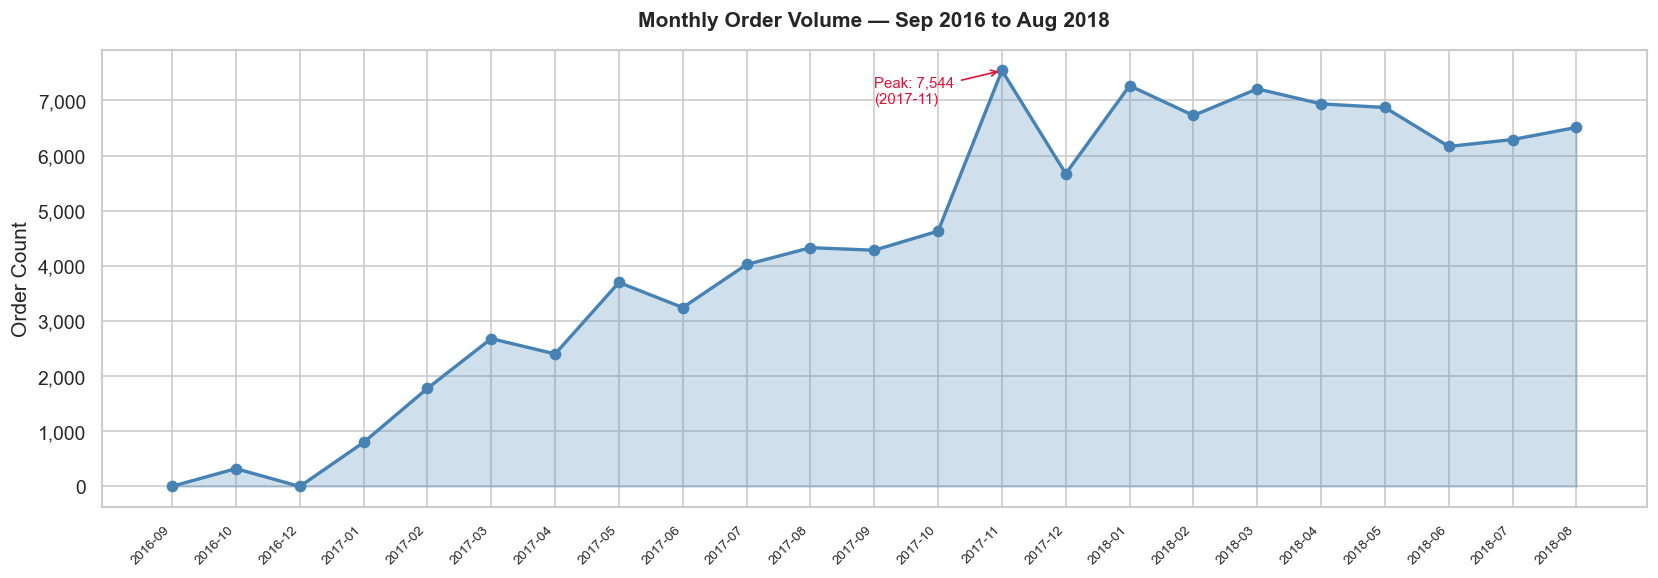

In [23]:
monthly_pd = (
    df_orders_raw
    .filter(F.col('order_purchase_timestamp').isNotNull())
    .withColumn('ym', F.date_format('order_purchase_timestamp', 'yyyy-MM'))
    .groupBy('ym').count()
    .orderBy('ym')
    .toPandas()
)
# exclude Sep/Oct 2018 — only 4/16 orders (incomplete months)
monthly_pd = monthly_pd[monthly_pd['ym'] < '2018-09']

fig, ax = plt.subplots(figsize=(14, 5), dpi=FIG_DPI)
ax.fill_between(range(len(monthly_pd)), monthly_pd['count'], alpha=0.25, color='steelblue')
ax.plot(range(len(monthly_pd)), monthly_pd['count'], marker='o', color='steelblue', linewidth=2)

# annotate peak
peak_idx = monthly_pd['count'].idxmax()
ax.annotate(
    f"Peak: {monthly_pd.loc[peak_idx,'count']:,}\n({monthly_pd.loc[peak_idx,'ym']})",
    xy=(list(monthly_pd.index).index(peak_idx), monthly_pd.loc[peak_idx,'count']),
    xytext=(list(monthly_pd.index).index(peak_idx)-2, monthly_pd.loc[peak_idx,'count']-600),
    arrowprops=dict(arrowstyle='->', color='crimson'),
    color='crimson', fontsize=9
)

ax.set_xticks(range(len(monthly_pd)))
ax.set_xticklabels(monthly_pd['ym'], rotation=45, ha='right', fontsize=8)
ax.set_title('Monthly Order Volume — Sep 2016 to Aug 2018', pad=TITLE_PAD, fontweight='bold')
ax.set_ylabel('Order Count')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

### 7.3 Hourly & Day-of-Week Purchasing Patterns

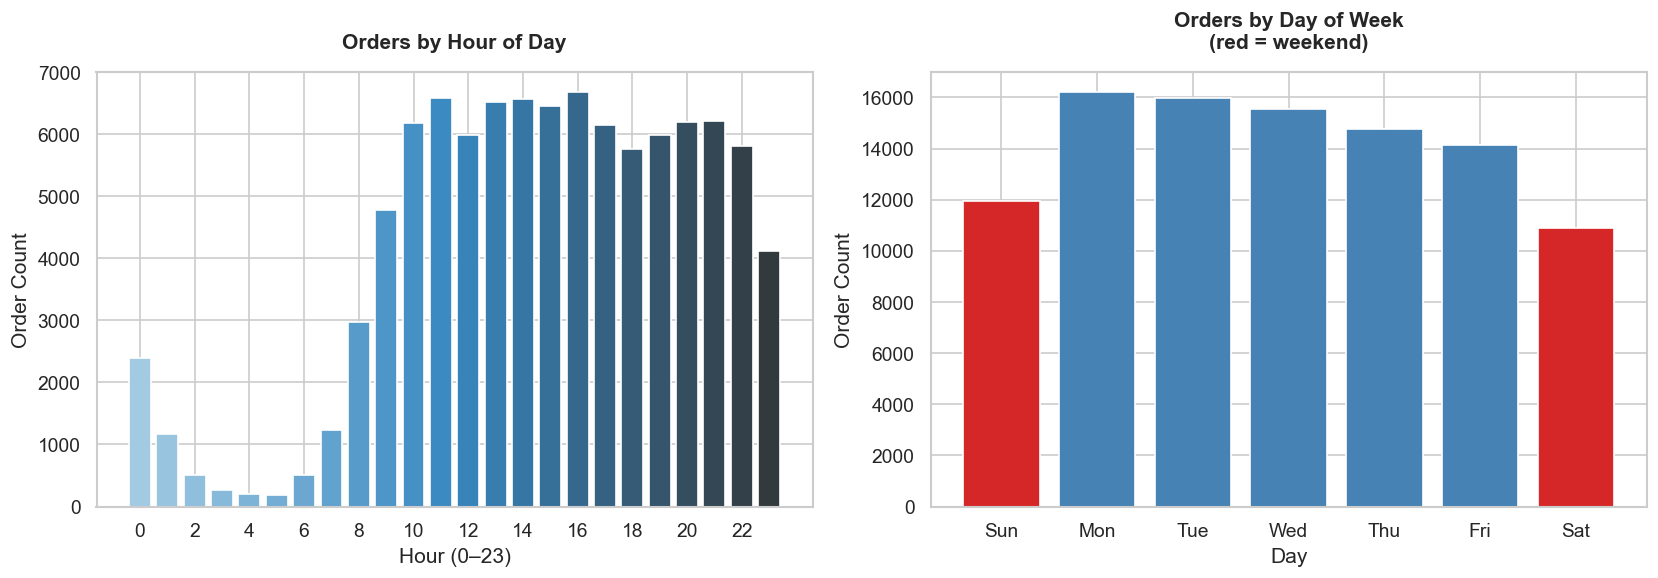

In [24]:
hourly_pd = (
    df_orders_raw
    .filter(F.col('order_purchase_timestamp').isNotNull())
    .withColumn('hr', F.hour('order_purchase_timestamp'))
    .groupBy('hr').count().orderBy('hr')
    .toPandas()
)

dow_pd = (
    df_orders_raw
    .filter(F.col('order_purchase_timestamp').isNotNull())
    .withColumn('dow', F.dayofweek('order_purchase_timestamp'))  # 1=Sun
    .groupBy('dow').count().orderBy('dow')
    .toPandas()
)
dow_pd['day_name'] = ['Sun','Mon','Tue','Wed','Thu','Fri','Sat']

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

axes[0].bar(hourly_pd['hr'], hourly_pd['count'],
            color=sns.color_palette('Blues_d', 24), edgecolor='white')
axes[0].set_title('Orders by Hour of Day', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Hour (0–23)')
axes[0].set_ylabel('Order Count')
axes[0].set_xticks(range(0,24,2))

palette = ['#d62728' if d in ['Sun','Sat'] else 'steelblue' for d in dow_pd['day_name']]
axes[1].bar(dow_pd['day_name'], dow_pd['count'], color=palette, edgecolor='white')
axes[1].set_title('Orders by Day of Week\n(red = weekend)', pad=TITLE_PAD, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Order Count')

plt.tight_layout()
plt.show()

### 7.4 Delivery Days Distribution

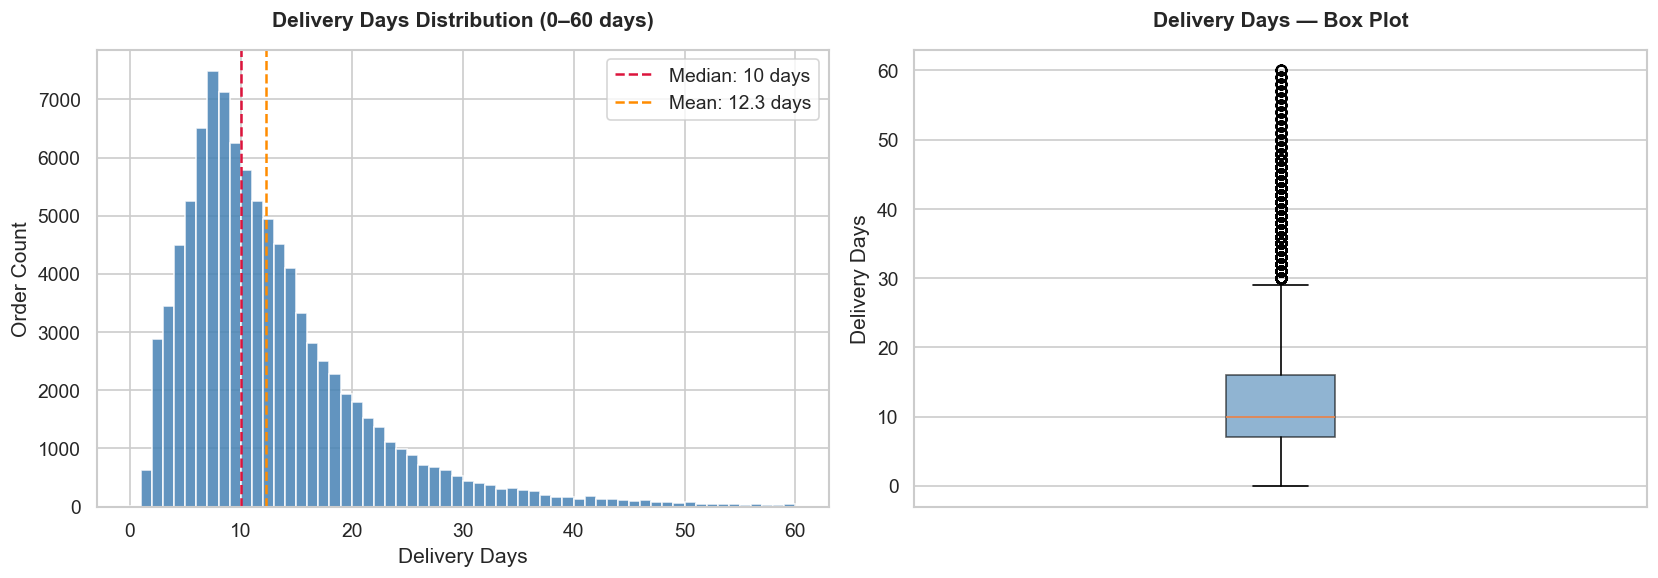

Delivery days summary:
count    96172.00
mean        12.26
std          8.39
min          0.00
25%          7.00
50%         10.00
75%         16.00
max         60.00
Name: delivery_days, dtype: float64


In [25]:
deliv_pd = (
    df_orders_raw
    .filter(
        (F.col('order_status') == 'delivered') &
        F.col('order_delivered_customer_date').isNotNull()
    )
    .withColumn('delivery_days',
        F.datediff('order_delivered_customer_date', 'order_purchase_timestamp')
    )
    .select('delivery_days')
    .toPandas()
)
deliv_pd = deliv_pd[(deliv_pd['delivery_days'] >= 0) & (deliv_pd['delivery_days'] <= 60)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=FIG_DPI)

axes[0].hist(deliv_pd['delivery_days'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(deliv_pd['delivery_days'].median(), color='crimson', linestyle='--', linewidth=1.5,
                label=f"Median: {deliv_pd['delivery_days'].median():.0f} days")
axes[0].axvline(deliv_pd['delivery_days'].mean(), color='darkorange', linestyle='--', linewidth=1.5,
                label=f"Mean: {deliv_pd['delivery_days'].mean():.1f} days")
axes[0].set_title('Delivery Days Distribution (0–60 days)', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Delivery Days')
axes[0].set_ylabel('Order Count')
axes[0].legend()

axes[1].boxplot(deliv_pd['delivery_days'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Delivery Days — Box Plot', pad=TITLE_PAD, fontweight='bold')
axes[1].set_ylabel('Delivery Days')
axes[1].set_xticks([])

plt.tight_layout()
plt.show()

print('Delivery days summary:')
print(deliv_pd['delivery_days'].describe().round(2))

## 8. Order Items — Price & Freight EDA

### 8.1 Price Distribution

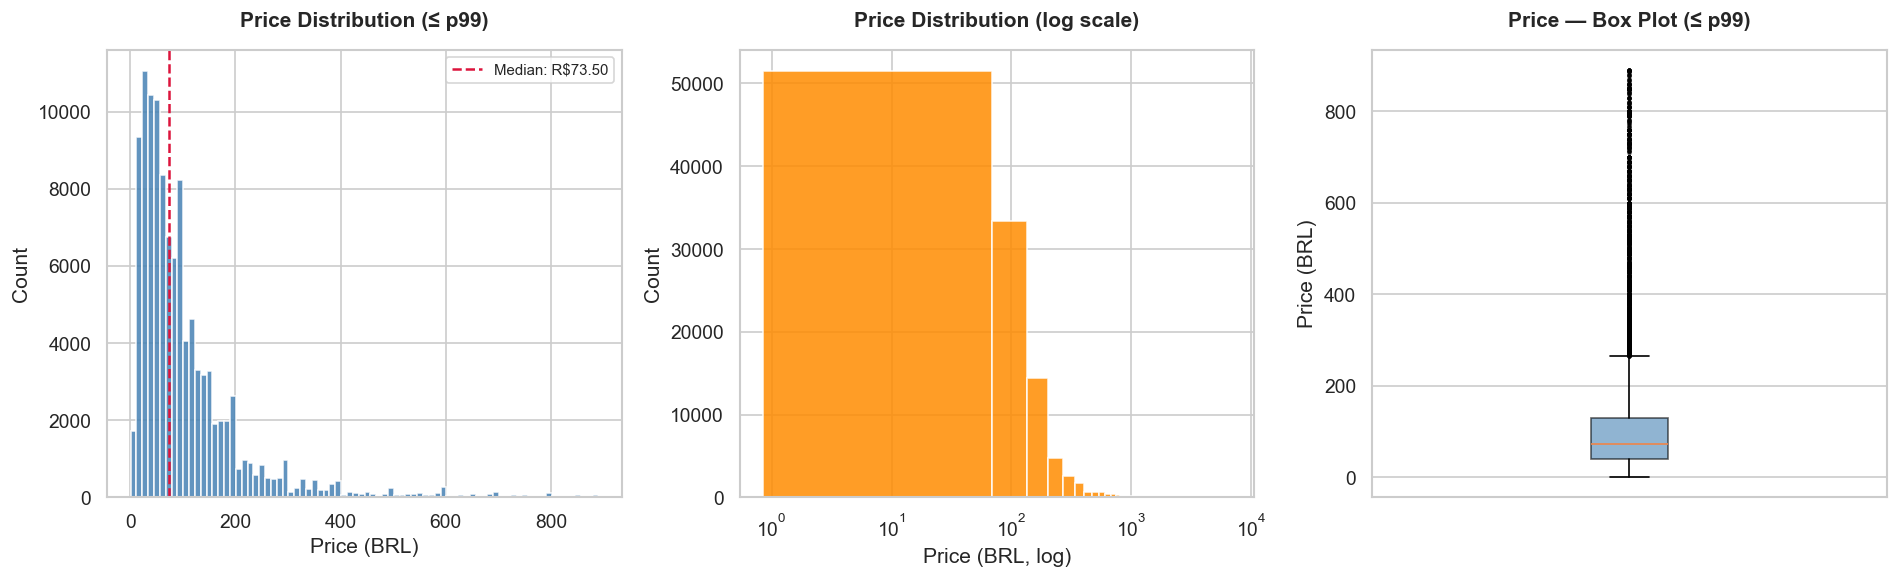

Price percentiles:
0.01       9.99
0.05      17.00
0.25      39.90
0.50      74.99
0.75     134.90
0.90     229.80
0.95     349.90
0.99     890.00
1.00    6735.00
Name: price, dtype: float64


In [26]:
price_pd = df_items_raw.select('price').toPandas()
price_clip = price_pd[price_pd['price'] <= price_pd['price'].quantile(0.99)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=FIG_DPI)

# histogram (clipped at p99)
axes[0].hist(price_clip['price'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(price_clip['price'].median(), color='crimson', linestyle='--', linewidth=1.5,
                label=f"Median: R${price_clip['price'].median():.2f}")
axes[0].set_title('Price Distribution (≤ p99)', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Price (BRL)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# log-scale histogram — reveals full range
axes[1].hist(price_pd['price'], bins=100, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].set_xscale('log')
axes[1].set_title('Price Distribution (log scale)', pad=TITLE_PAD, fontweight='bold')
axes[1].set_xlabel('Price (BRL, log)')
axes[1].set_ylabel('Count')

# box plot
axes[2].boxplot(price_clip['price'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6),
                flierprops=dict(marker='.', markersize=3, alpha=0.3))
axes[2].set_title('Price — Box Plot (≤ p99)', pad=TITLE_PAD, fontweight='bold')
axes[2].set_ylabel('Price (BRL)')
axes[2].set_xticks([])

plt.tight_layout()
plt.show()

print('Price percentiles:')
print(price_pd['price'].quantile([0.01,0.05,0.25,0.5,0.75,0.90,0.95,0.99,1.0]).round(2))

### 8.2 Freight Value Distribution

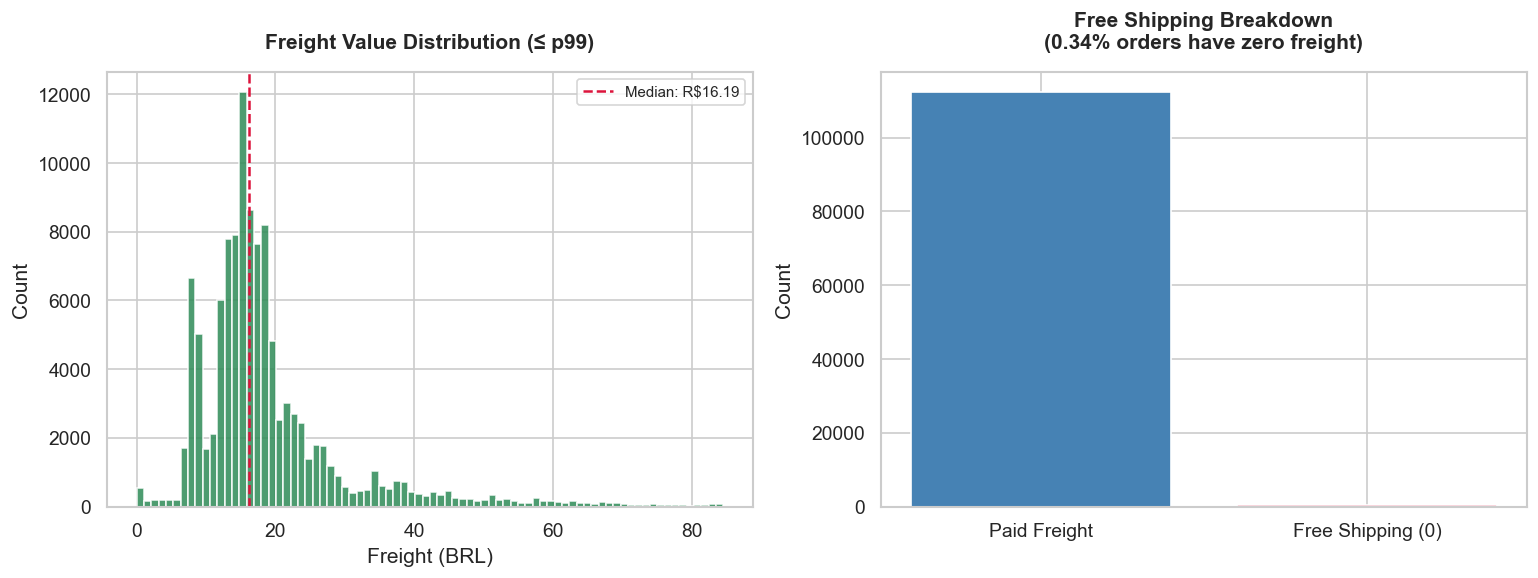

In [27]:
freight_pd = df_items_raw.select('freight_value').toPandas()
freight_clip = freight_pd[freight_pd['freight_value'] <= freight_pd['freight_value'].quantile(0.99)]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), dpi=FIG_DPI)

axes[0].hist(freight_clip['freight_value'], bins=80, color='seagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(freight_clip['freight_value'].median(), color='crimson', linestyle='--',
                linewidth=1.5, label=f"Median: R${freight_clip['freight_value'].median():.2f}")
axes[0].set_title('Freight Value Distribution (≤ p99)', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Freight (BRL)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# zero-freight flag
zero_pct = (freight_pd['freight_value'] == 0).sum() / len(freight_pd) * 100
axes[1].bar(['Paid Freight', 'Free Shipping (0)'],
            [len(freight_pd) - (freight_pd['freight_value']==0).sum(),
             (freight_pd['freight_value']==0).sum()],
            color=['steelblue','crimson'], edgecolor='white')
axes[1].set_title(f'Free Shipping Breakdown\n({zero_pct:.2f}% orders have zero freight)',
                  pad=TITLE_PAD, fontweight='bold')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

### 8.3 Items per Order Distribution

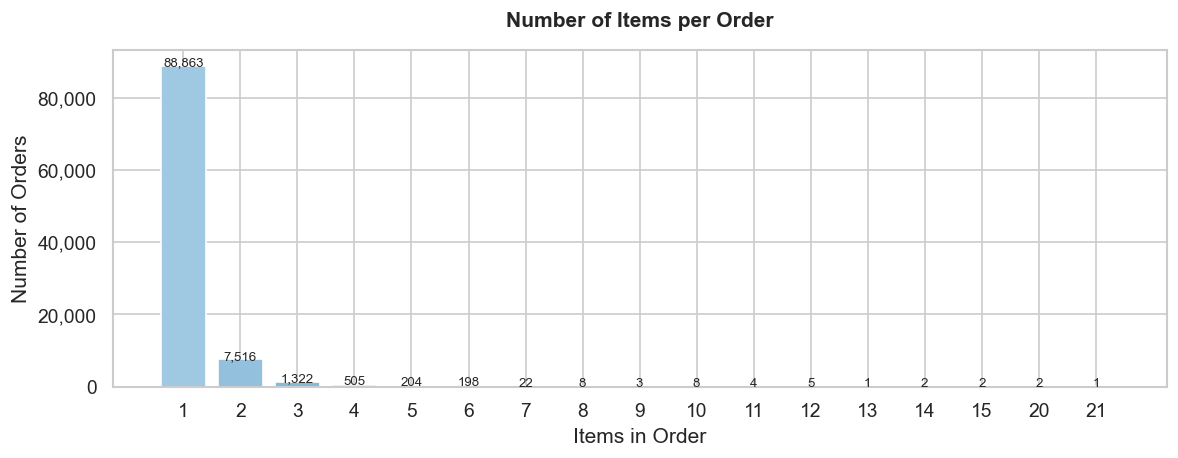

Single-item orders: 88,863 / 98,666  (90.1%)


In [28]:
items_per_order_pd = (
    df_items_raw
    .groupBy('order_id')
    .agg(F.max('order_item_id').alias('item_count'))
    .groupBy('item_count').count()
    .orderBy('item_count')
    .toPandas()
)

fig, ax = plt.subplots(figsize=(10, 4), dpi=FIG_DPI)
bars = ax.bar(items_per_order_pd['item_count'].astype(str),
              items_per_order_pd['count'],
              color=sns.color_palette('Blues_d', len(items_per_order_pd)), edgecolor='white')
for bar, val in zip(bars, items_per_order_pd['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f'{val:,}', ha='center', fontsize=8)
ax.set_title('Number of Items per Order', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('Items in Order')
ax.set_ylabel('Number of Orders')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()

single_pct = items_per_order_pd.loc[items_per_order_pd['item_count']==1,'count'].values[0]
total_orders = items_per_order_pd['count'].sum()
print(f'Single-item orders: {single_pct:,} / {total_orders:,}  ({single_pct/total_orders*100:.1f}%)')

## 9. Products — Category & Physical Attributes EDA

### 9.1 Top 20 Categories by Order Volume

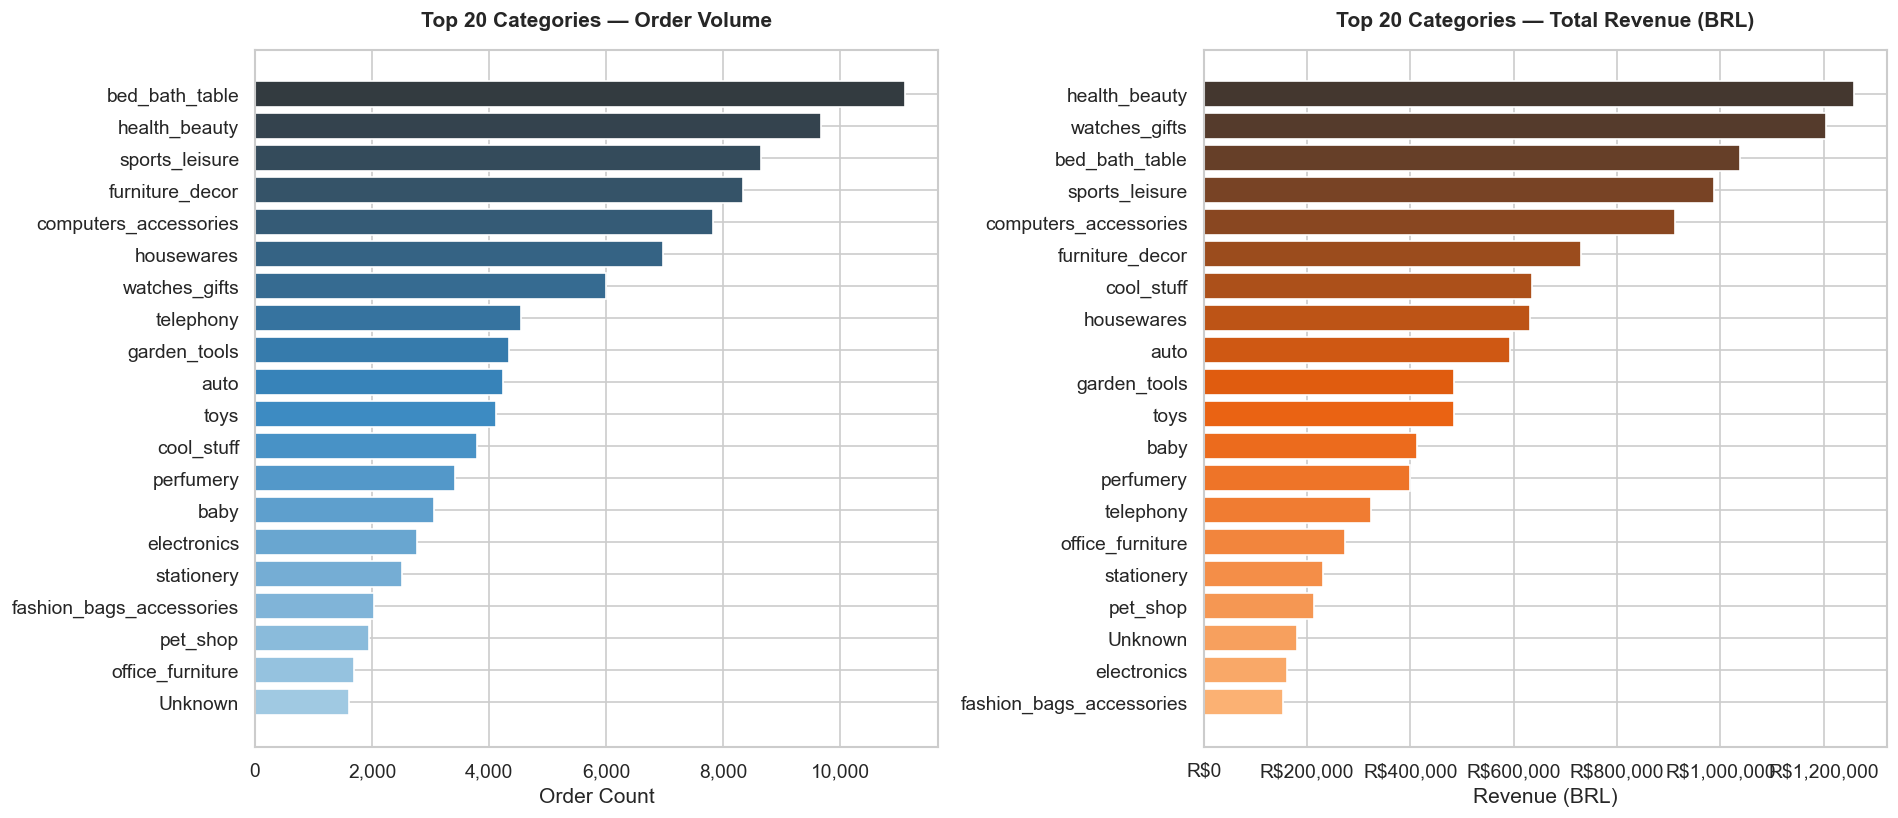

             category_en  order_count  total_revenue  avg_price
          bed_bath_table        11115     1036988.68      93.30
           health_beauty         9670     1258681.34     130.16
          sports_leisure         8641      988048.97     114.34
         furniture_decor         8334      729762.49      87.56
   computers_accessories         7827      911954.32     116.51
              housewares         6964      632248.66      90.79
           watches_gifts         5991     1205005.68     201.14
               telephony         4545      323667.53      71.21
            garden_tools         4347      485256.46     111.63
                    auto         4235      592720.11     139.96
                    toys         4117      483946.60     117.55
              cool_stuff         3796      635290.85     167.36
               perfumery         3419      399124.87     116.74
                    baby         3065      411764.89     134.34
             electronics         2767   

In [30]:
# join items → products → translation for English labels
cat_vol_pd = (
    df_items_raw
    .join(df_products_raw.select('product_id','product_category_name'), on='product_id', how='left')
    .join(df_translation_raw, on='product_category_name', how='left')
    .withColumn('category_en',
        F.coalesce(F.col('product_category_name_english'), F.col('product_category_name'),  F.lit('Unknown'))
    )
    .groupBy('category_en')
    .agg(
        F.count('order_id').alias('order_count'),
        F.round(F.sum('price'), 2).alias('total_revenue'),
        F.round(F.avg('price'), 2).alias('avg_price')
    )
    .orderBy(F.desc('order_count'))
    .limit(20)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=FIG_DPI)

# by volume
cat_vol_sorted = cat_vol_pd.sort_values('order_count')
axes[0].barh(cat_vol_sorted['category_en'], cat_vol_sorted['order_count'],
             color=sns.color_palette('Blues_d', 20), edgecolor='white')
axes[0].set_title('Top 20 Categories — Order Volume', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('Order Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# by revenue
cat_rev_sorted = cat_vol_pd.sort_values('total_revenue')
axes[1].barh(cat_rev_sorted['category_en'], cat_rev_sorted['total_revenue'],
             color=sns.color_palette('Oranges_d', 20), edgecolor='white')
axes[1].set_title('Top 20 Categories — Total Revenue (BRL)', pad=TITLE_PAD, fontweight='bold')
axes[1].set_xlabel('Revenue (BRL)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${int(x):,}'))

plt.tight_layout()
plt.show()
print(cat_vol_pd.to_string(index=False))

### 9.2 Average Price per Category (Top 20 by Revenue)

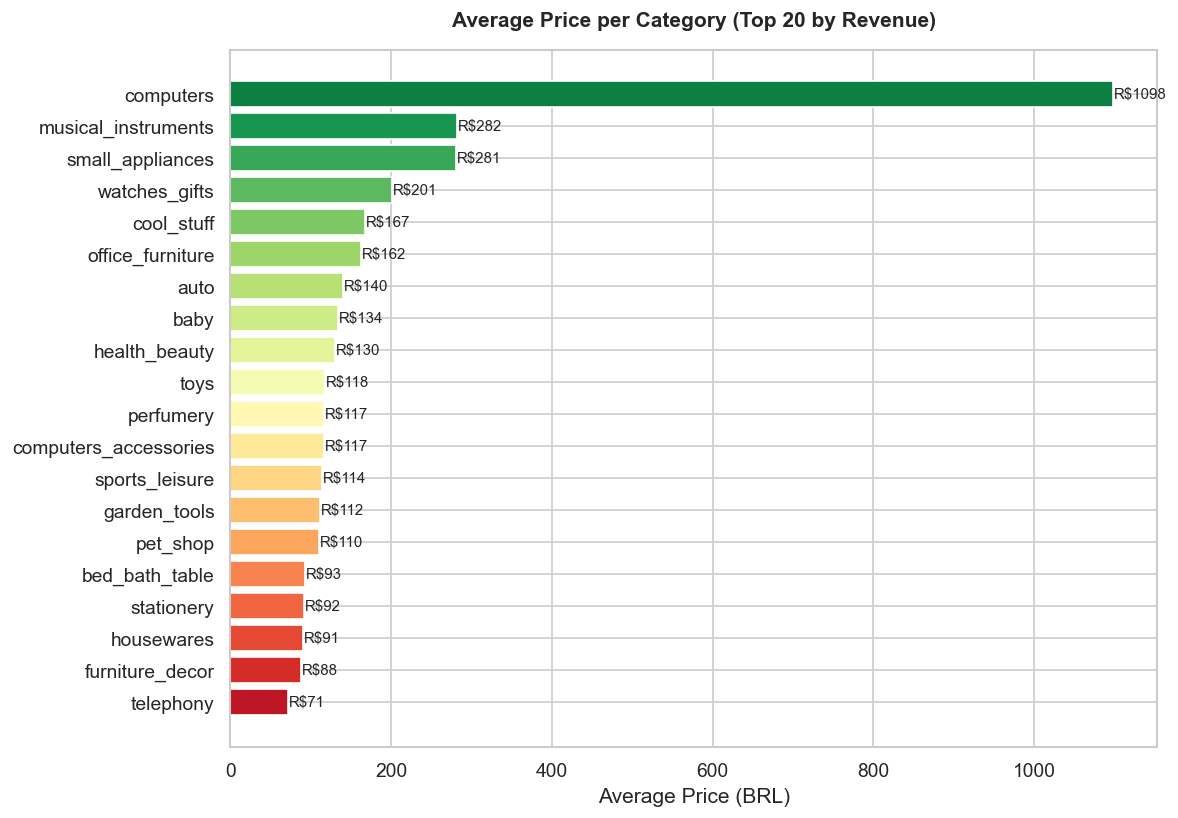

In [31]:
cat_price_pd = (
    df_items_raw
    .join(df_products_raw.select('product_id','product_category_name'), on='product_id', how='left')
    .join(df_translation_raw, on='product_category_name', how='left')
    .withColumn('category_en',
        F.coalesce(F.col('product_category_name_english'), F.col('product_category_name'))
    )
    .groupBy('category_en')
    .agg(
        F.round(F.avg('price'), 2).alias('avg_price'),
        F.round(F.sum('price'), 2).alias('total_revenue')
    )
    .orderBy(F.desc('total_revenue'))
    .limit(20)
    .toPandas()
    .sort_values('avg_price')
)

fig, ax = plt.subplots(figsize=(10, 7), dpi=FIG_DPI)
bars = ax.barh(cat_price_pd['category_en'], cat_price_pd['avg_price'],
               color=sns.color_palette('RdYlGn', len(cat_price_pd)), edgecolor='white')
for bar, val in zip(bars, cat_price_pd['avg_price']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'R${val:.0f}', va='center', fontsize=9)
ax.set_title('Average Price per Category (Top 20 by Revenue)', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('Average Price (BRL)')
plt.tight_layout()
plt.show()

### 9.3 Product Physical Attributes Distribution

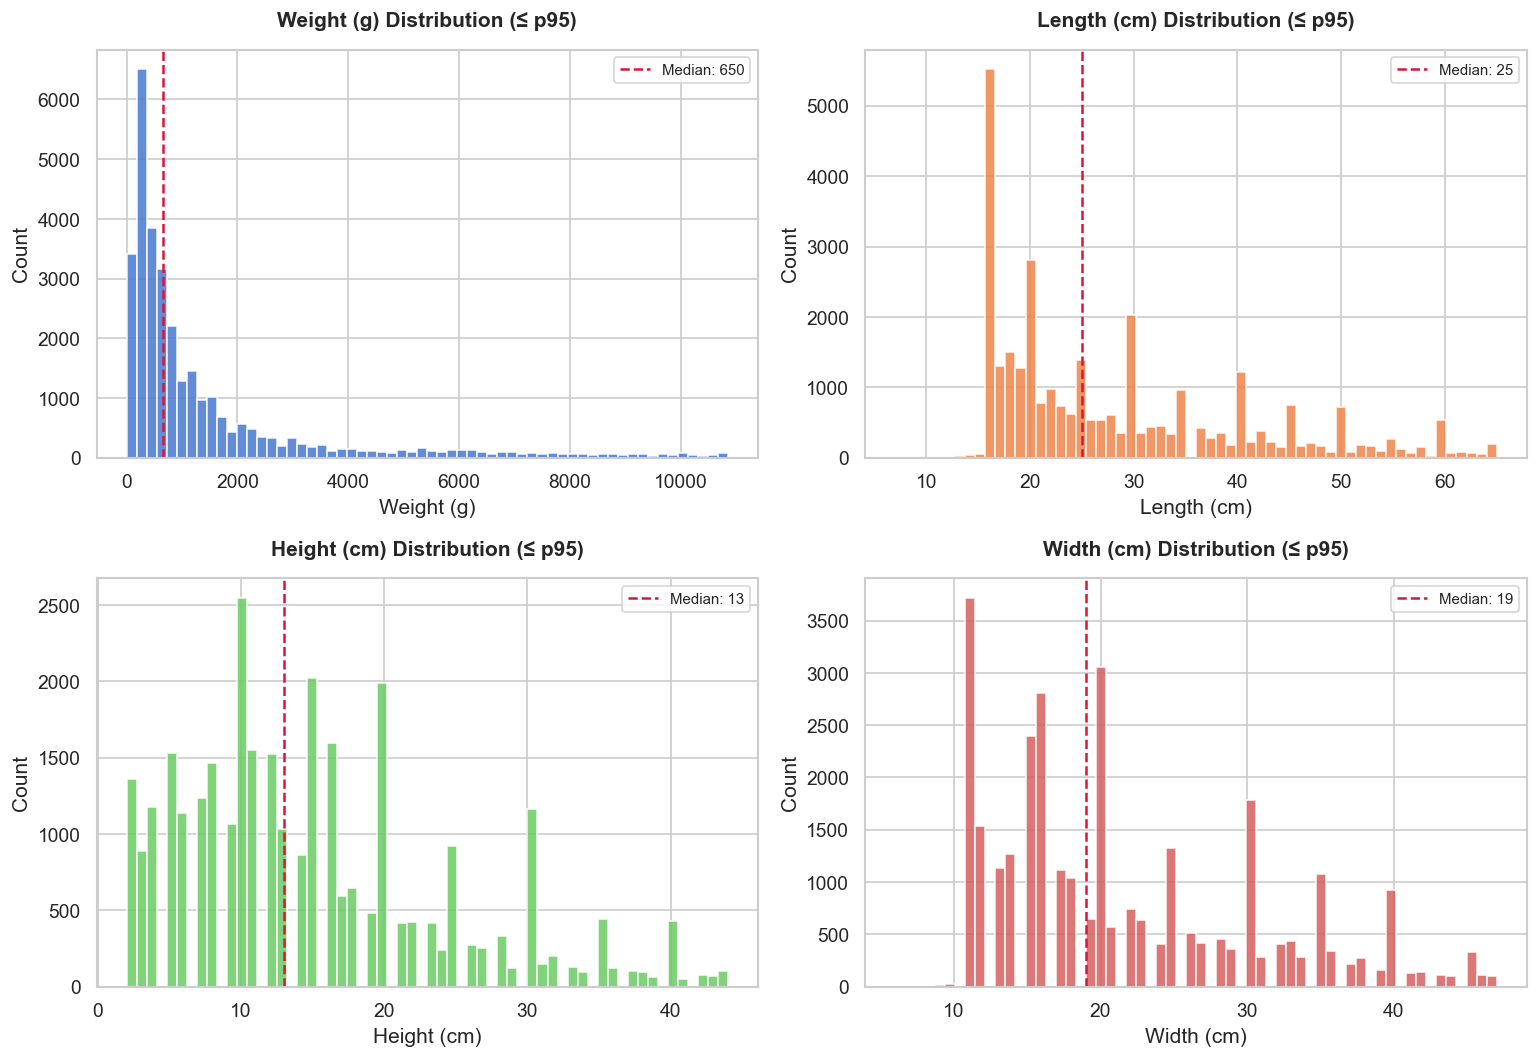

In [32]:
phys_pd = df_products_raw.select(
    'product_weight_g','product_length_cm','product_height_cm','product_width_cm'
).toPandas()

cols  = ['product_weight_g','product_length_cm','product_height_cm','product_width_cm']
caps  = [phys_pd[c].quantile(0.95) for c in cols]   # clip at p95 for readability
labels= ['Weight (g)','Length (cm)','Height (cm)','Width (cm)']

fig, axes = plt.subplots(2, 2, figsize=(13, 9), dpi=FIG_DPI)
axes = axes.flatten()

for i, (col, cap, lbl) in enumerate(zip(cols, caps, labels)):
    data = phys_pd[phys_pd[col] <= cap][col].dropna()
    axes[i].hist(data, bins=60, color=sns.color_palette('muted')[i], edgecolor='white', alpha=0.85)
    axes[i].axvline(data.median(), color='crimson', linestyle='--', linewidth=1.5,
                    label=f'Median: {data.median():.0f}')
    axes[i].set_title(f'{lbl} Distribution (≤ p95)', pad=TITLE_PAD, fontweight='bold')
    axes[i].set_xlabel(lbl)
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.tight_layout()
plt.show()

## 10. Customers — Geography EDA

### 10.1 Orders by Brazilian State

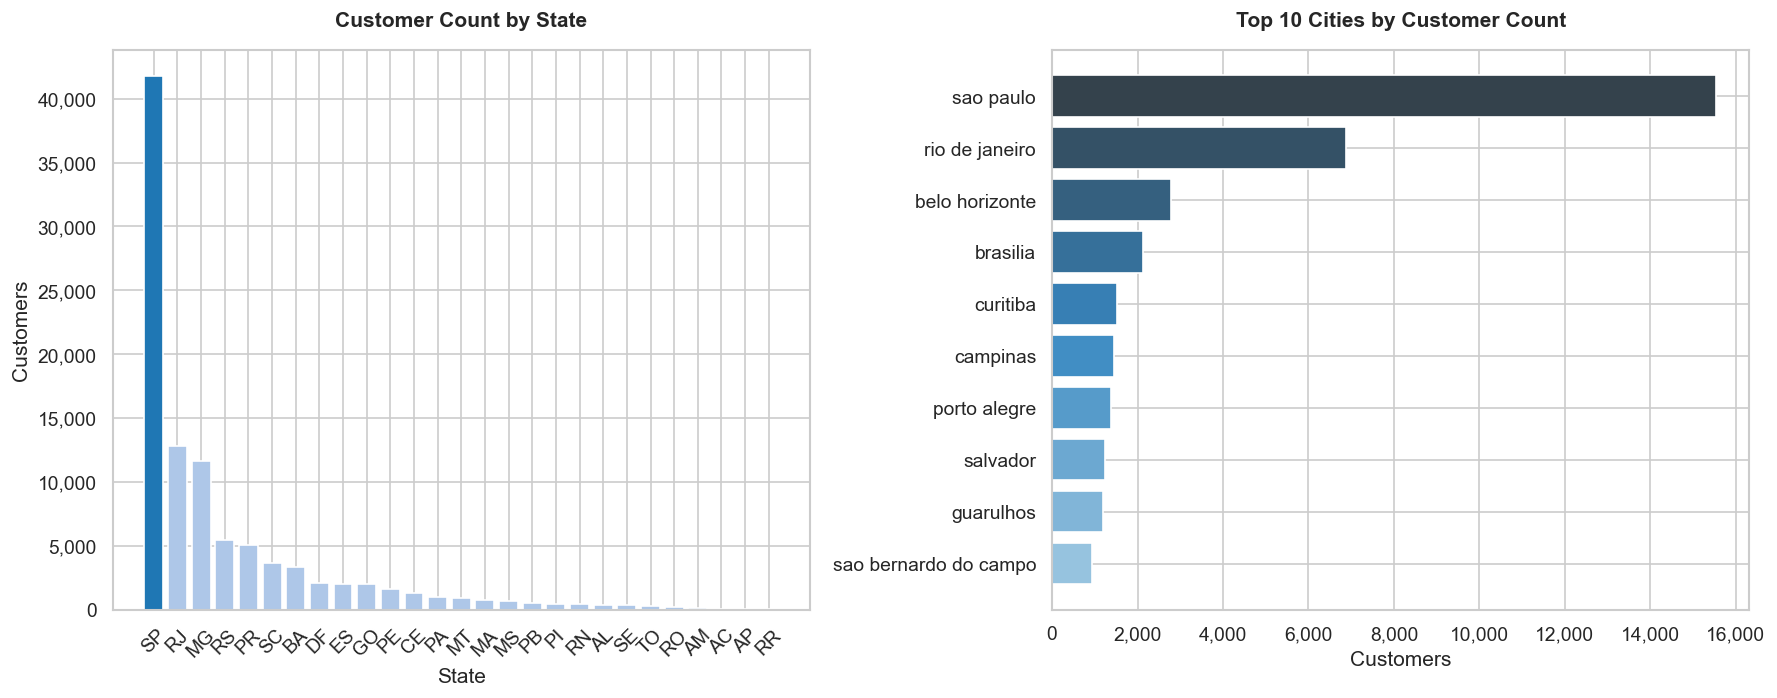

customer_state  count
            SP  41746
            RJ  12852
            MG  11635
            RS   5466
            PR   5045
            SC   3637
            BA   3380
            DF   2140
            ES   2033
            GO   2020
            PE   1652
            CE   1336
            PA    975
            MT    907
            MA    747
            MS    715
            PB    536
            PI    495
            RN    485
            AL    413
            SE    350
            TO    280
            RO    253
            AM    148
            AC     81
            AP     68
            RR     46


In [33]:
state_pd = (
    df_customers_raw
    .groupBy('customer_state').count()
    .orderBy(F.desc('count'))
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=FIG_DPI)

# bar
palette = ['#1f77b4' if s == 'SP' else '#aec7e8' for s in state_pd['customer_state']]
bars = axes[0].bar(state_pd['customer_state'], state_pd['count'],
                   color=palette, edgecolor='white')
axes[0].set_title('Customer Count by State', pad=TITLE_PAD, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=45)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# top 10 cities
city_pd = (
    df_customers_raw
    .withColumn('customer_city', F.trim(F.lower(F.col('customer_city'))))
    .groupBy('customer_city').count()
    .orderBy(F.desc('count'))
    .limit(10)
    .toPandas()
    .sort_values('count')
)
axes[1].barh(city_pd['customer_city'], city_pd['count'],
             color=sns.color_palette('Blues_d', 10), edgecolor='white')
axes[1].set_title('Top 10 Cities by Customer Count', pad=TITLE_PAD, fontweight='bold')
axes[1].set_xlabel('Customers')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()
print(state_pd.to_string(index=False))

## 11. Outlier Detection

### 11.1 Price Outlier Detection — IQR Method

IQR          : 90.09
Lower fence  : -95.23  (no items below this — min price is R$0.85)
Upper fence  : 265.12  (mild outliers above)
Extreme fence: 400.26  (extreme outliers above)
Mild outliers    : 4,657  (4.13%)
Extreme outliers : 4,239  (3.76%)


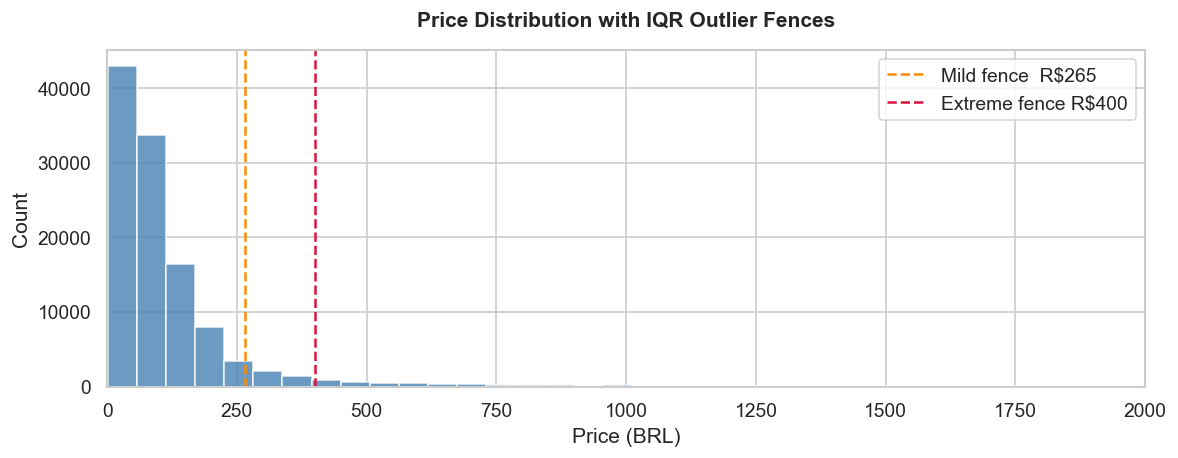

In [34]:
q1, q3 = df_items_raw.approxQuantile('price', [0.25, 0.75], relativeError=0.01)
iqr = q3 - q1
lower_fence = q1 - 1.5 * iqr
upper_fence = q3 + 1.5 * iqr
extreme_fence = q3 + 3.0 * iqr

mild_outliers    = df_items_raw.filter((F.col('price') > upper_fence) & (F.col('price') <= extreme_fence)).count()
extreme_outliers = df_items_raw.filter(F.col('price') > extreme_fence).count()
total_items      = df_items_raw.count()

print(f'IQR          : {iqr:.2f}')
print(f'Lower fence  : {lower_fence:.2f}  (no items below this — min price is R$0.85)')
print(f'Upper fence  : {upper_fence:.2f}  (mild outliers above)')
print(f'Extreme fence: {extreme_fence:.2f}  (extreme outliers above)')
print(f'Mild outliers    : {mild_outliers:,}  ({mild_outliers/total_items*100:.2f}%)')
print(f'Extreme outliers : {extreme_outliers:,}  ({extreme_outliers/total_items*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 4), dpi=FIG_DPI)
price_pd2 = df_items_raw.select('price').toPandas()
ax.hist(price_pd2['price'], bins=120, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(upper_fence,  color='darkorange', linestyle='--', linewidth=1.5, label=f'Mild fence  R${upper_fence:.0f}')
ax.axvline(extreme_fence,color='crimson',    linestyle='--', linewidth=1.5, label=f'Extreme fence R${extreme_fence:.0f}')
ax.set_xlim(0, 2000)
ax.set_title('Price Distribution with IQR Outlier Fences', pad=TITLE_PAD, fontweight='bold')
ax.set_xlabel('Price (BRL)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()